# Distribution des années de naissance dans le temps

Cette page se donne pour but de documenter la distribution des années de naissances dans le temps de la populations choisie – ici les sociologues – afin de faire émerger différentes générations. La distribution prendra également en compte le facteur du genre afin de voir comme celui-ci évolue dans le temps.

In [3]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Import des données

In [5]:
## create variable declaring the path to the data
path_to_data = 'data_analysis/da1_data/birth-dates-gender.csv'

In [6]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)

## first rows of the dataframe
df_p.head()

,s,label,birthDate,genLabel
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male
2,<http://www.wikidata.org/entity/Q12310818>,Eyvind Vesselbo,1946,male
3,<http://www.wikidata.org/entity/Q113785774>,Eva-Maria Schrage,1982,female
4,<http://www.wikidata.org/entity/Q1329359>,Elijah Anderson,1943,male


In [7]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   s          10000 non-null  object
 1   label      10000 non-null  object
 2   birthDate  10000 non-null  int64 
 3   genLabel   10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [8]:
### Rename a column
df_p = df_p.rename(columns={'birthDate': 'birthYear'})

In [9]:
### Select the first values of this column
df_p.birthYear.head()

0    1946
1    1937
2    1946
3    1982
4    1943
Name: birthYear, dtype: int64

# Add a column to the DataFrame containing the gender code

In [10]:
### First, we create a function that performs the intended task

## The argument of the ‘code_gender’ function is a name of your choice
# It is then referenced within the function as a variable
# and holds the value entered when the function is called

def code_gender(genLabel):
    if genLabel == 'male':
        # genre masculin
        a = 'M'
    elif genLabel =='female':
        # genre féminin
        a = 'F'
    else:
        # genre autre
        a = 'A'
    return a 

In [11]:
### We test if the function works
print(code_gender('female'))

F


In [12]:
### Add a new column and enter the result of the function in each row
df_p['genCode'] = df_p.apply(lambda x: code_gender(x['genLabel']), axis=1)

In [13]:
### We examine the first five rows that have the value ‘A’ = other
df_p[df_p['genCode']=='A'][:5]

,s,label,birthYear,genLabel,genCode
1265,<http://www.wikidata.org/entity/Q106632699>,Emmanuel Beaubatie,1986,trans man,A
1923,<http://www.wikidata.org/entity/Q111016751>,Bruce Arrigo,1960,undisclosed gender,A
2286,<http://www.wikidata.org/entity/Q117009720>,Aurore Koechlin,1988,cisgender woman,A
3629,<http://www.wikidata.org/entity/Q112290402>,Teresa L. Scheid,1957,undisclosed gender,A
5019,<http://www.wikidata.org/entity/Q110723024>,Finn Mackay,1977,transmasculine,A


In [14]:
### Group by gender and count  
df_p.groupby("genCode").size()   # .reset_index(name="count")

genCode
A      10
F    3111
M    6879
dtype: int64

# Effectifs par année

In [15]:
### We inspect the values in the ‘birthYear’ column 
# and check what the data type is
df_p['birthYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: birthYear
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [16]:
### If it's an integer (int64) there's nothig to do 
# Otherwise, we change the data type of the BirthYear column
# from 'object' (text) to 'integer'
df_p['birthYear'] = df_p['birthYear'].astype(int)

In [17]:
### On regroupe les données par année et on compte le nombre de naissances par année
# On créé un nouveau DataFrame comme résultat
years_count = pd.DataFrame(df_p.groupby('birthYear').size()).reset_index()
years_count.columns=['year','number']
years_count

,year,number
0,1783,1
1,1796,1
2,1797,1
3,1798,1
4,1801,1
...,...,...
178,1995,6
179,1996,7
180,1997,5
181,1998,1


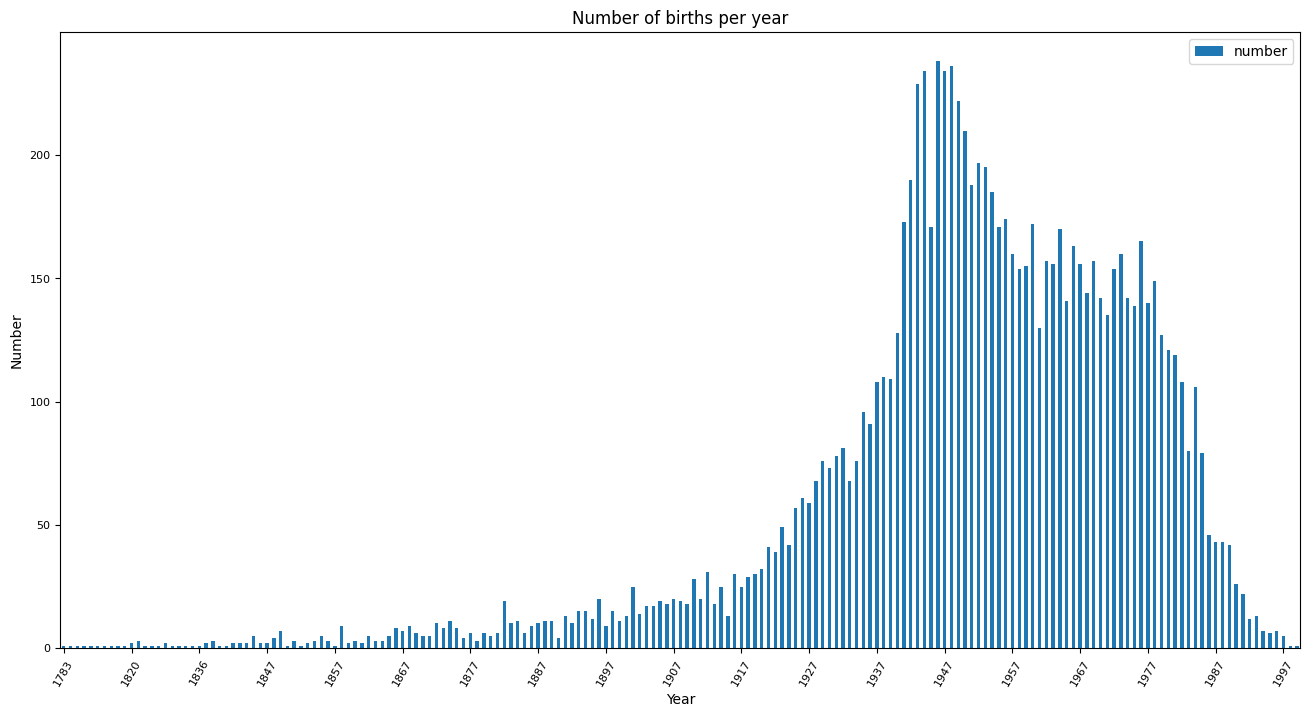

In [18]:
### Représentation graphique des effectifs par année

ax = years_count.plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year')
plt.show()

# Issues if years are missing
We delete some years here, although available in reality, in order to illustrate the bias and the solution

In [19]:
## Apparently all years are available with some number of persons born
# But what would happen if a year is missing
missing_years = pd.Index(range(years_count['year'].min(), years_count['year'].max() + 1)).difference(years_count['year']).tolist()
print(missing_years)  # Output: [1902, 1904]

[1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1799, 1800, 1802, 1803, 1804, 1806, 1807, 1808, 1809, 1812, 1813, 1814, 1816, 1817, 1818, 1821, 1825, 1827, 1830, 1831, 1834, 1838]


In [20]:
### We randomly delete some years as if there were no births that year
years_count = years_count[~years_count['number'].isin([10,20,30, 40, 50])]

In [21]:
df_y = pd.DataFrame({'year':range(years_count['year'].min(), years_count['year'].max() + 1)})
df_y.head()

,year
0,1783
1,1784
2,1785
3,1786
4,1787


In [22]:
merged = df_y.merge(years_count, on='year', how='left')

In [23]:
merged.head(10)

,year,number
0,1783,1.0
1,1784,NaN
2,1785,NaN
3,1786,NaN
4,1787,NaN
5,1788,NaN
6,1789,NaN
7,1790,NaN
8,1791,NaN
9,1792,NaN


In [24]:
merged['number'] = merged[['number']].fillna(0)

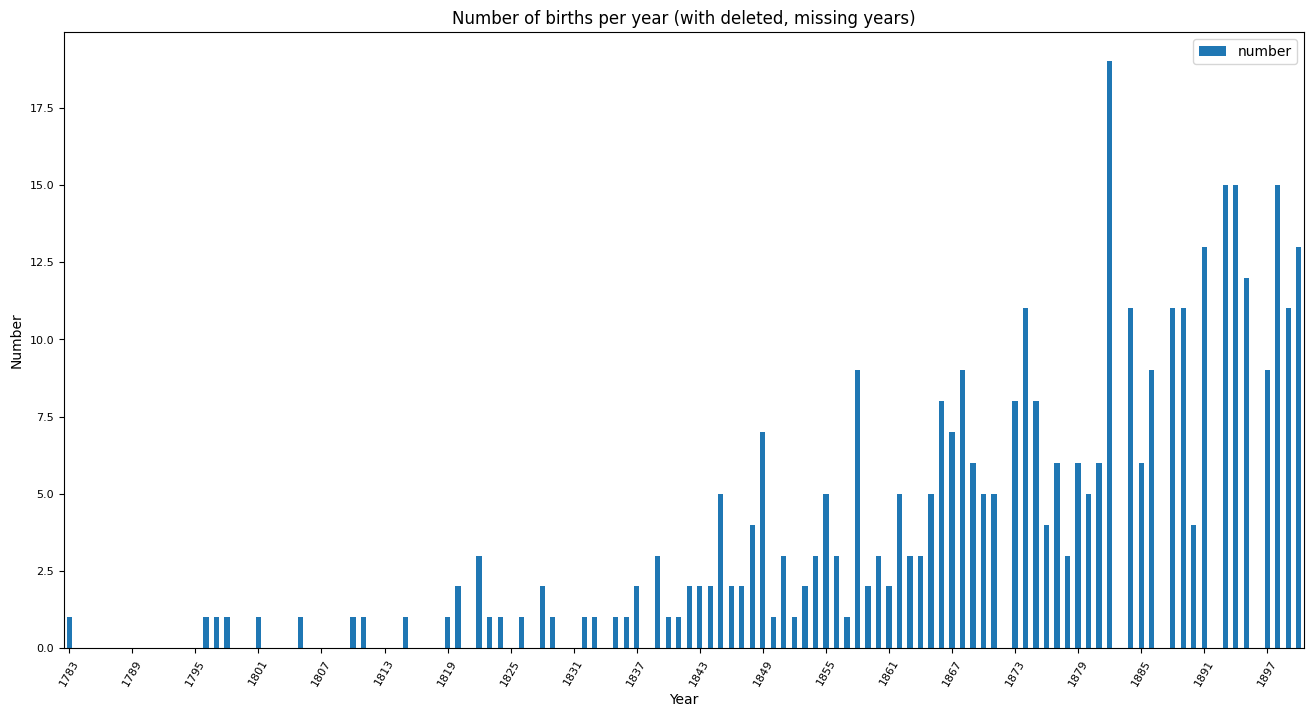

In [25]:
### Représentation graphique des effectifs par année

ax = merged[merged.year < 1901].plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year (with deleted, missing years)')
plt.show()

# Group by 20-year period

In [26]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
cdf_p = df_p.copy(deep=True)

In [27]:
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male,M
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male,M
2,<http://www.wikidata.org/entity/Q12310818>,Eyvind Vesselbo,1946,male,M


In [28]:
### Année minimale et maximale dans la population
print(min(cdf_p['birthYear']), max(cdf_p['birthYear']))

1783 1999


# Codage par périodes de 25 ans

In [29]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781, 2001, 20))
print(l_20[:5],l_20[-5:])

[1781, 1801, 1821, 1841, 1861] [1901, 1921, 1941, 1961, 1981]


In [30]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['birthYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male,M,1941-1960
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male,M,1921-1940
2,<http://www.wikidata.org/entity/Q12310818>,Eyvind Vesselbo,1946,male,M,1941-1960


In [31]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1781-1800       4
1801-1820       8
1821-1840      19
1841-1860      60
1861-1880     119
1881-1900     230
1901-1920     448
1921-1940    1510
1941-1960    3888
1961-1980    2948
dtype: int64

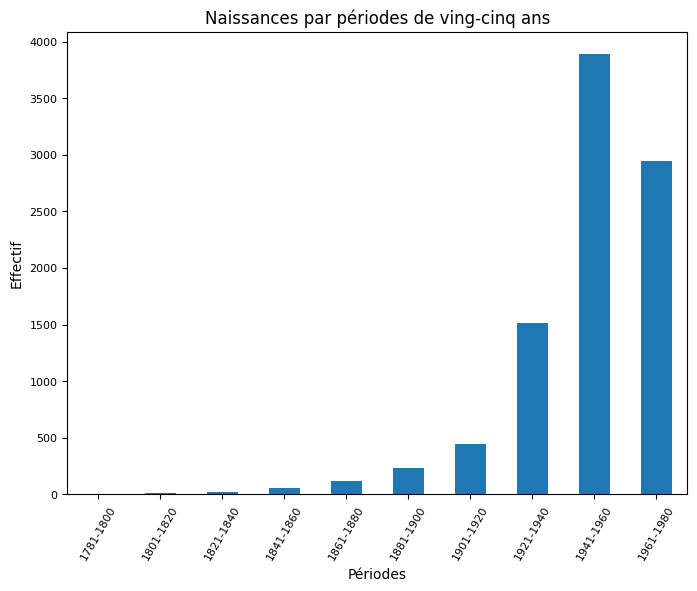

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8)
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Naissances par périodes de ving-cinq ans')

plt.show()

# Shift to activity date

In [33]:
### Add a new column and enter the result of the function in each row
cdf_p['activityYear'] = cdf_p.apply(lambda x: x['birthYear']+45, axis=1)

In [34]:
cdf_p.head(2)

,s,label,birthYear,genLabel,genCode,periodes,activityYear
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male,M,1941-1960,1991
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male,M,1921-1940,1982


In [35]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781+45, 2001+45, 20))
print(l_20[:5],l_20[-5:])

[1826, 1846, 1866, 1886, 1906] [1946, 1966, 1986, 2006, 2026]


In [36]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['activityYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes,activityYear
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male,M,1986-2005,1991
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male,M,1966-1985,1982
2,<http://www.wikidata.org/entity/Q12310818>,Eyvind Vesselbo,1946,male,M,1986-2005,1991


In [37]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1826-1845       4
1846-1865       8
1866-1885      19
1886-1905      60
1906-1925     119
1926-1945     230
1946-1965     448
1966-1985    1510
1986-2005    3888
2006-2025    2948
dtype: int64

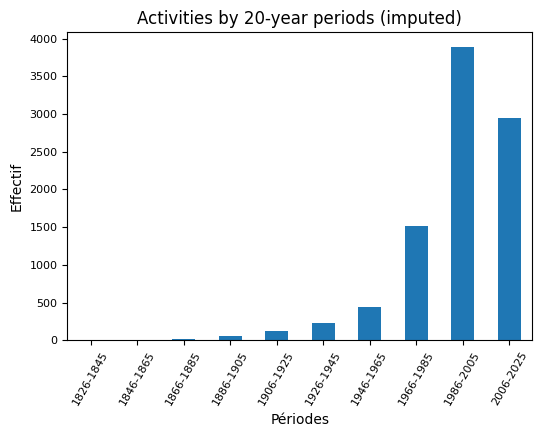

In [38]:
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8, figsize=(6, 4))
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Activities by 20-year periods (imputed)')
plt.show()

# Ajouter la représentation des genres
Only female and male, other are omitted because their number is too small for a representation.
They should be inspected separately.

In [39]:
### Regrouper et compter avec un fitre sur le genre masculin
gender_m = pd.DataFrame(cdf_p[cdf_p.genCode == 'M'].groupby('periodes', observed=False).size())
gender_m.columns = ['m']
gender_m.tail()

,m
periodes,
1926-1945,208
1946-1965,394
1966-1985,1237
1986-2005,2771
2006-2025,1705


In [40]:
### Regrouper et compter avec un fitre sur le genre féminin
gender_f = pd.DataFrame(cdf_p[cdf_p.genCode == 'F'].groupby('periodes').size())
gender_f.columns = ['f']
gender_f.tail()

,f
periodes,
1926-1945,22
1946-1965,54
1966-1985,273
1986-2005,1114
2006-2025,1240


In [41]:
### Fusionner les deux tableaux en utilisant l'index comme clé de jointure
merged = pd.merge(gender_m, gender_f, left_index=True, right_index=True)
merged.tail()

,m,f
periodes,,
1926-1945,208,22
1946-1965,394,54
1966-1985,1237,273
1986-2005,2771,1114
2006-2025,1705,1240


In [42]:
### Transformer l'index de séquence à chaîne de caractères
# ce qui est indispensable pour l'affichage dans un graphique
merged.index = merged.index.map(str)
merged.tail()

,m,f
periodes,,
1926-1945,208,22
1946-1965,394,54
1966-1985,1237,273
1986-2005,2771,1114
2006-2025,1705,1240


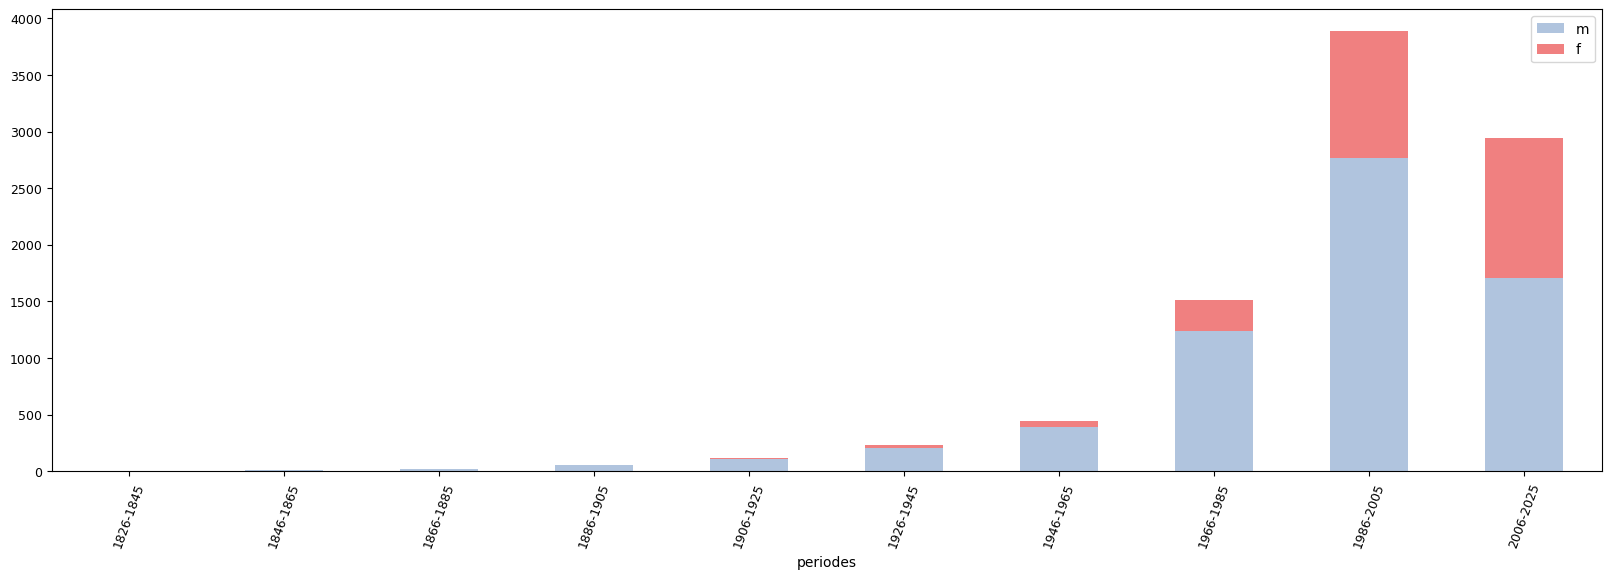

In [43]:
### Documentation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
ax = merged.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(20,6), color=['LightSteelBlue', 'LightCoral'])
plt.show()

# Coding of imputed activity dates by ten-year period
Comme on voit bien dans le graphique précédent qu'il y a deux périodes avec des effectifs radicalements différents, on restraint la période analysée à l'époque contemporaine et on affine avec un découpage par périodes de dix ans.

In [44]:
l_10 = list(range(1781+45, 1991+45, 10))
print(l_10[:5],l_10[-5:])

[1826, 1836, 1846, 1856, 1866] [1986, 1996, 2006, 2016, 2026]


In [45]:
### Découpage par décennies
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

cdf_p['per_10'] = pd.cut(cdf_p['activityYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['per_10'] = cdf_p['per_10'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes,activityYear,per_10
0,<http://www.wikidata.org/entity/Q113730844>,Ivo Lesbaupin,1946,male,M,1986-2005,1991,1986-1995
1,<http://www.wikidata.org/entity/Q112540238>,Jon P. Alston,1937,male,M,1966-1985,1982,1976-1985
2,<http://www.wikidata.org/entity/Q12310818>,Eyvind Vesselbo,1946,male,M,1986-2005,1991,1986-1995


In [46]:
### On regroupe par genre comme ci-dessus
gender_m_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'M') ].groupby('per_10').size())
gender_m_10.columns = ['m']
gender_m_10.tail()

,m
per_10,
1976-1985,767
1986-1995,1580
1996-2005,1191
2006-2015,941
2016-2025,764


In [47]:
### Idem
gender_f_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'F')& (cdf_p.birthYear > 1780)].groupby('per_10').size())
gender_f_10.columns = ['f']
gender_f_10.tail()

,f
per_10,
1976-1985,178
1986-1995,556
1996-2005,558
2006-2015,574
2016-2025,666


In [48]:
merged_10 = pd.merge(gender_m_10, gender_f_10, left_index=True, right_index=True)
merged_10.tail()

,m,f
per_10,,
1976-1985,767,178
1986-1995,1580,556
1996-2005,1191,558
2006-2015,941,574
2016-2025,764,666


In [49]:
### On transforme le type de valeur de l'index
# et on ajoute une colonne avec le total
merged_10.index = merged_10.index.map(str)
merged_10['tot']=merged_10['m']+merged_10['f']
merged_10.tail()

,m,f,tot
per_10,,,
1976-1985,767,178,945
1986-1995,1580,556,2136
1996-2005,1191,558,1749
2006-2015,941,574,1515
2016-2025,764,666,1430


In [50]:
merged_10.head()

,m,f,tot
per_10,,,
1826-1835,1,0,1
1836-1845,3,0,3
1846-1855,3,0,3
1856-1865,5,0,5
1866-1875,9,0,9


In [51]:
m_10_not_zero = merged_10[merged_10.f > 0]
m_10_not_zero

,m,f,tot
per_10,,,
1886-1895,27,1,28
1896-1905,27,5,32
1906-1915,51,2,53
1916-1925,58,8,66
1926-1935,91,6,97
1936-1945,117,16,133
1946-1955,173,22,195
1956-1965,221,32,253
1966-1975,470,95,565


In [52]:
### On prépare les valeurs pour l'affichage des fréquences (proportion par rapport au total)

# liste qui contient toutes les valeurs à la suite
m_f = m_10_not_zero.m.to_list()+m_10_not_zero.f.to_list()

# liste d'égale longueur que la précédente qui contient 
# les valeurs de l'index, i.e. les périodes
tot = m_10_not_zero.tot.to_list()*2

# liste qui contient les valeurs des fréquences
lp = [round(v/t, 2) for v,t in zip(m_f, tot)]
print(lp[:3])

[0.96, 0.84, 0.96]


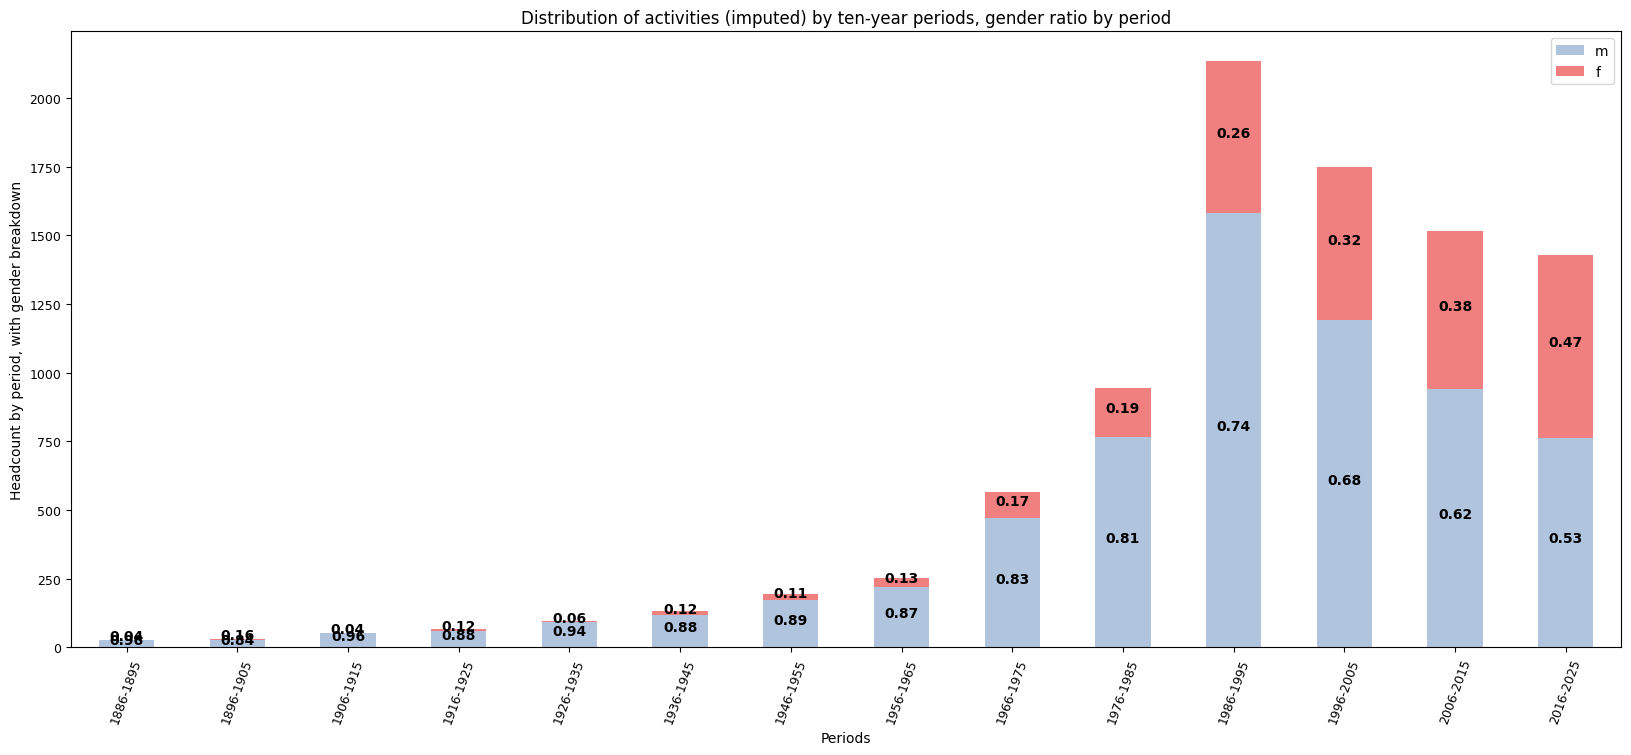

In [55]:
### Graphique avec la distribution par période et genre (M,F)
# Noter que les effectifs du genre 'Autres' étant très faibles,
# on ne les analyse pas de manière sérielle mais on peut les analyser qualitatiement

ax = m_10_not_zero.plot.bar(stacked=True, y=['m', 'f'], \
                        rot=70, fontsize=9, figsize=(20,8), color=['LightSteelBlue', 'LightCoral'])


### https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/


## On ajoute une étiquette concernant la valeur de fréquence
# à chaque rectangle dans le graphe, en utilisant la list 'lp' préparée précédemment
# Il y a autant de triangles que les valeurs d'index x le nombre de variables

for bar,v in zip(ax.patches,lp): 

    ax.text(
      # Met les étiquette aux centre des rectangles
      bar.get_x() + bar.get_width() / 2,
        
      # Ajoute les coordonnées verticales
      bar.get_height()/2 + bar.get_y(), 
      
      # Ajoute les valeurs
      v,

      # centre et met du style aux étiquettes
      ha='center',
      color='black',
      weight='bold',
      size=10
  )

plt.ylabel('Headcount by period, with gender breakdown')
plt.xlabel('Periods')
plt.title('Distribution of activities (imputed) by ten-year periods, gender ratio by period')

## On peut enregistrer l'image dans un fichier (noter le dossier créé préalablement)
# qu'on pourra ensuite introduire dans un travail et commenter

# Doc.: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
plt.savefig('images/naissances_distribution_10ans_genre.jpg', bbox_inches='tight',
                       pad_inches=0.2)
plt.show()

# New interactive chart using Plotly

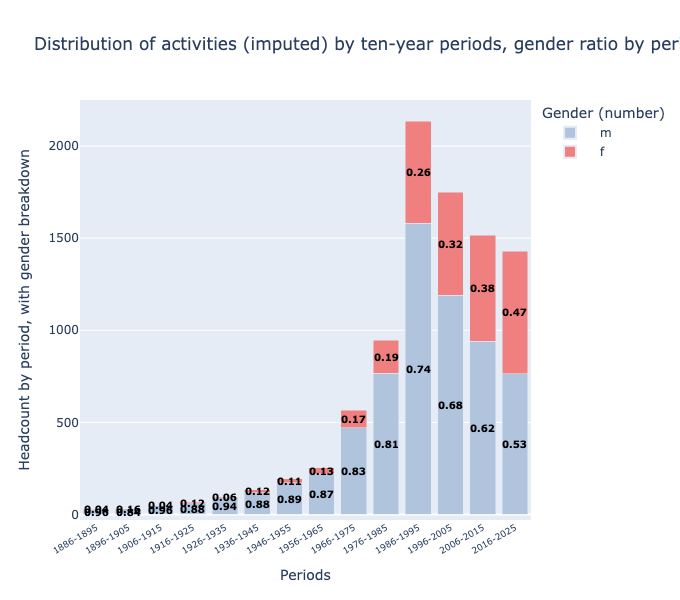

In [57]:
# Reset index to make 'per_10' a column
df_plot = m_10_not_zero.reset_index()

# Calculate percentages per period
df_plot['tot'] = df_plot['m'] + df_plot['f']
df_plot['pct_m'] = df_plot['m'] / df_plot['tot']
df_plot['pct_f'] = df_plot['f'] / df_plot['tot']

# Create stacked bar chart
fig = px.bar(
    df_plot,
    x='per_10',
    y=['m', 'f'],
    color_discrete_map={'m': 'LightSteelBlue', 'f': 'LightCoral'},
    title='Distribution of activities (imputed) by ten-year periods, gender ratio by period',
    labels={'per_10': 'Periods', 'value': 'Number', 'variable': 'Genre'},
    barmode='stack'
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=-30, tickfont=dict(size=9))

# Add percentage labels inside bars
for i, row in df_plot.iterrows():
    # Add m percentage label
    if row['m'] > 0:
        pct_m_str = f"{row['pct_m']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] / 2,
            text=pct_m_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )
    # Add f percentage label
    if row['f'] > 0:
        pct_f_str = f"{row['pct_f']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] + row['f'] / 2,
            text=pct_f_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )

# Customize hover info to show actual counts
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Number %{fullData.name}: %{y}<extra></extra>'
)

# Update layout
fig.update_layout(
    yaxis_title='Headcount by period, with gender breakdown',
    font=dict(size=12),
    width=1000,
    height=600,
    legend_title_text='Gender',
    legend=dict(
        title=dict(text="Gender (number)"),
        itemsizing='constant',
        itemwidth=50
    )
)

# Optional: Customize legend to show counts (e.g., "m (244)")
fig.for_each_trace(lambda t: t.update(name=f"{t.name}") if t.name in ['m', 'f'] else t)   # ({df_plot[t.name].iloc[0]})

# Save as interactive HTML
fig.write_html("interactive_images/naissances_distribution_10ans_genre_percent.html", include_plotlyjs='cdn', full_html=True)

# Optional: Show in notebook or browser
fig.show()